In [2]:
!pip install -q h2o

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 4.3 MB/s eta 0:00:00


In [3]:
# standard
import numpy as np
import pandas as pd

# plots
import matplotlib.pyplot as plt
import seaborn as sns

# statistics
from scipy import stats

# machine learning tools
from sklearn.model_selection import train_test_split
import h2o
from h2o.estimators import H2OGeneralizedLinearEstimator, H2OGradientBoostingEstimator

In [5]:
# configs
pd.set_option('display.max_columns', None) # we want to display all columns in this notebook

# aesthetics
default_color_1 = 'darkblue'
default_color_2 = 'darkgreen'
default_color_3 = 'darkred'


In [7]:
df = pd.read_csv('osteoporosis[1].csv')

In [8]:
# preview
df.head(10)

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
0,1734616,69,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
1,1419098,32,Female,Normal,Yes,Asian,Underweight,Low,Sufficient,Sedentary,No,NaN,NaN,NaN,Yes,1
2,1797916,89,Female,Postmenopausal,No,Caucasian,Normal,Adequate,Sufficient,Active,No,Moderate,Hyperthyroidism,Corticosteroids,No,1
3,1805337,78,Female,Normal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
4,1351334,38,Male,Postmenopausal,Yes,African American,Normal,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,NaN,Yes,1
5,1799320,41,Male,Normal,Yes,Caucasian,Normal,Low,Sufficient,Active,Yes,Moderate,Rheumatoid Arthritis,Corticosteroids,Yes,1
6,1577644,20,Male,Postmenopausal,Yes,African American,Underweight,Adequate,Sufficient,Sedentary,No,NaN,Rheumatoid Arthritis,NaN,No,1
7,1443912,39,Male,Postmenopausal,Yes,Asian,Normal,Adequate,Sufficient,Sedentary,No,NaN,Rheumatoid Arthritis,Corticosteroids,Yes,1
8,1379331,70,Male,Postmenopausal,No,Asian,Underweight,Low,Sufficient,Active,Yes,NaN,Rheumatoid Arthritis,Corticosteroids,No,1
9,1824991,19,Female,Normal,No,African American,Normal,Low,Sufficient,Active,Yes,Moderate,NaN,Corticosteroids,Yes,1


In [9]:
# structure of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1958 entries, 0 to 1957
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Id                   1958 non-null   int64 
 1   Age                  1958 non-null   int64 
 2   Gender               1958 non-null   object
 3   Hormonal Changes     1958 non-null   object
 4   Family History       1958 non-null   object
 5   Race/Ethnicity       1958 non-null   object
 6   Body Weight          1958 non-null   object
 7   Calcium Intake       1958 non-null   object
 8   Vitamin D Intake     1958 non-null   object
 9   Physical Activity    1958 non-null   object
 10  Smoking              1958 non-null   object
 11  Alcohol Consumption  970 non-null    object
 12  Medical Conditions   1311 non-null   object
 13  Medications          973 non-null    object
 14  Prior Fractures      1958 non-null   object
 15  Osteoporosis         1958 non-null   int64 
dtypes: int

In [10]:
# basic stats
df.describe(include='all')

,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis
count,1.958000e+03,1958.000000,1958,1958,1958,1958,1958,1958,1958,1958,1958,970,1311,973,1958,1958.000000
unique,NaN,NaN,2,2,2,3,2,2,2,2,2,1,2,1,2,NaN
top,NaN,NaN,Male,Normal,No,African American,Normal,Low,Sufficient,Active,Yes,Moderate,Hyperthyroidism,Corticosteroids,Yes,NaN
freq,NaN,NaN,992,981,998,681,1027,1004,1011,1021,982,970,678,973,983,NaN
mean,1.549929e+06,39.101124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000
std,2.614250e+05,21.355424,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500128
min,1.100064e+06,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,1.319163e+06,21.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,1.546028e+06,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.500000
75%,1.775870e+06,53.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000


In [11]:
# define features
features_num = ['Age']

features_cat = ['Gender', 'Hormonal Changes', 'Family History',
                'Race/Ethnicity', 'Body Weight', 'Calcium Intake',
                'Vitamin D Intake', 'Physical Activity', 'Smoking',
                'Alcohol Consumption', 'Medical Conditions', 'Medications',
                'Prior Fractures']

target = 'Osteoporosis'

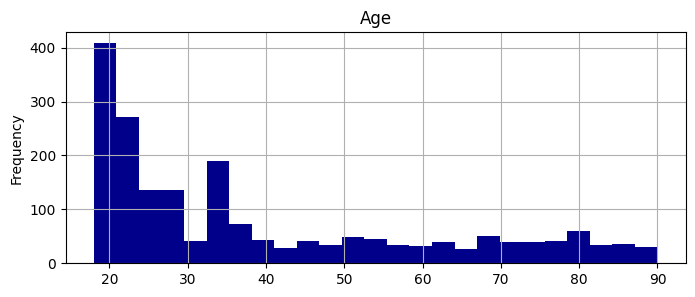

In [12]:
# plot histograms
for f in features_num:
    plt.figure(figsize=(8,3))
    df[f].plot(kind='hist', bins=25,
               color='darkblue')
    plt.title(f)
    plt.grid()
    plt.show()

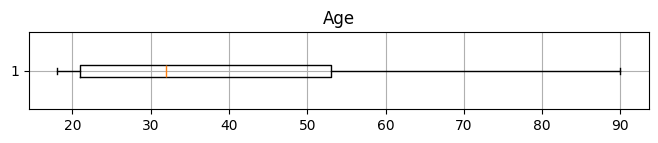

In [13]:
# boxplots
for f in features_num:
    plt.figure(figsize=(8,1))
    plt.boxplot(df[f], vert=False)
    plt.title(f)
    plt.grid()

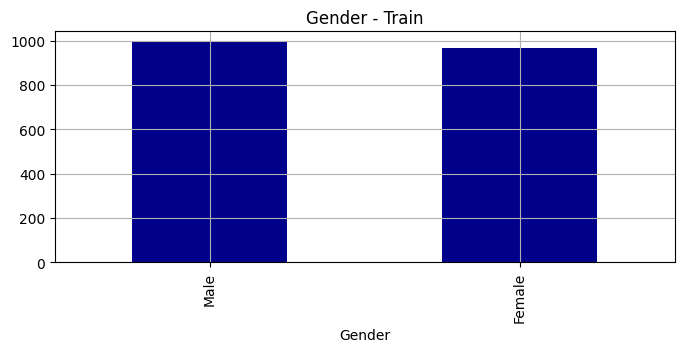

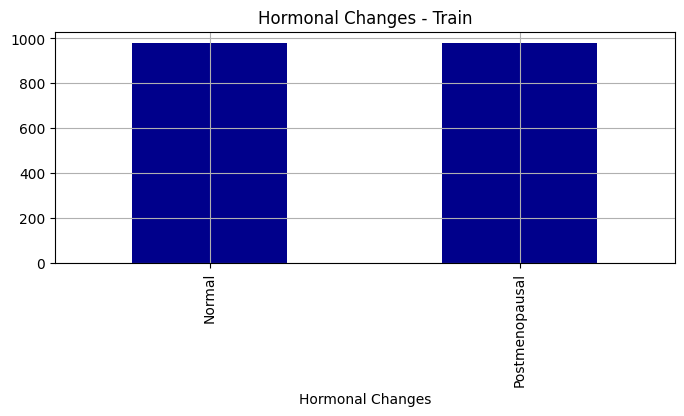

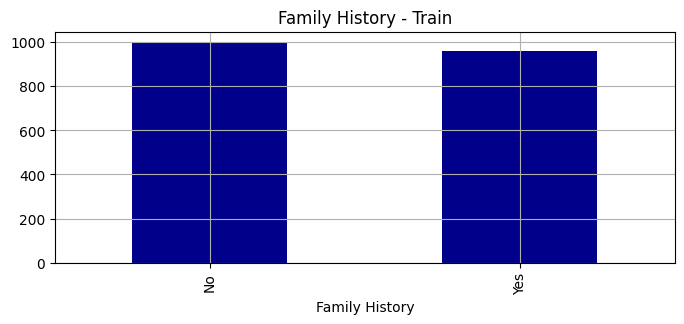

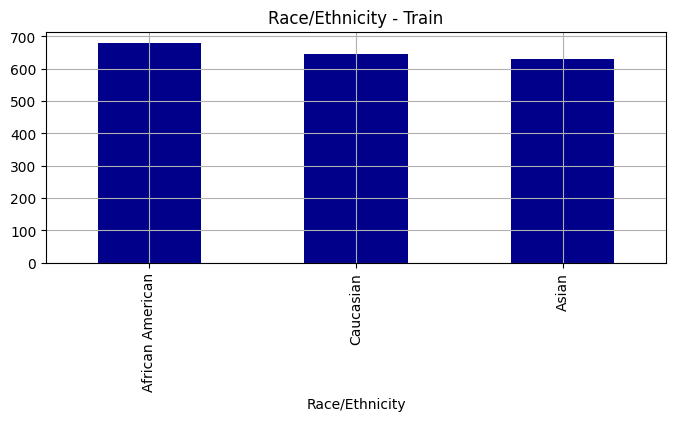

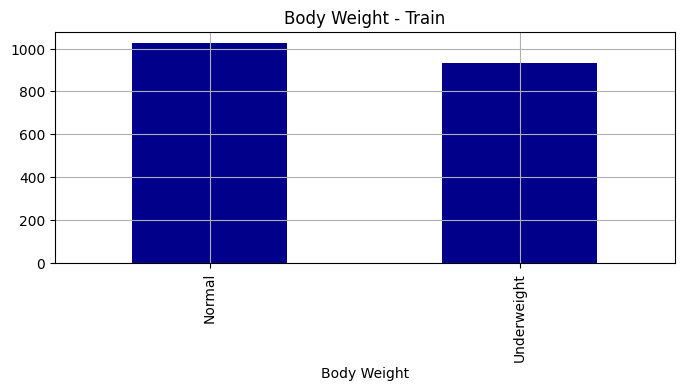

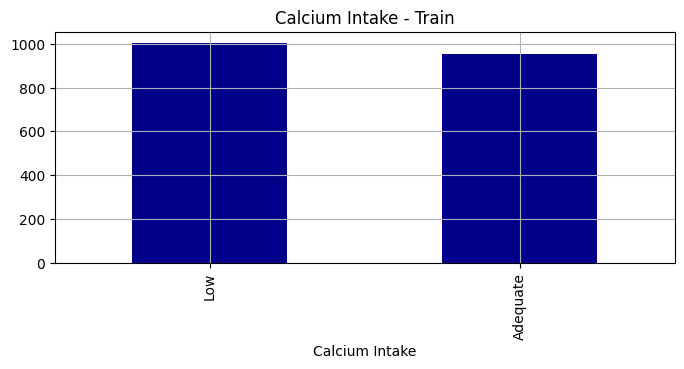

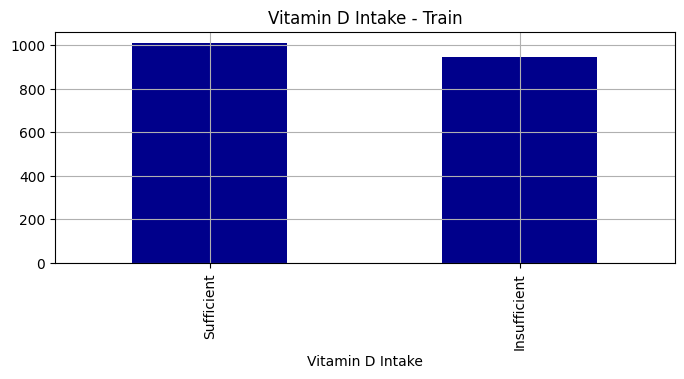

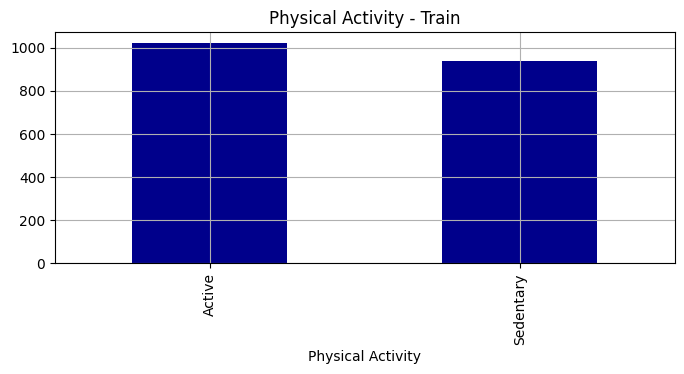

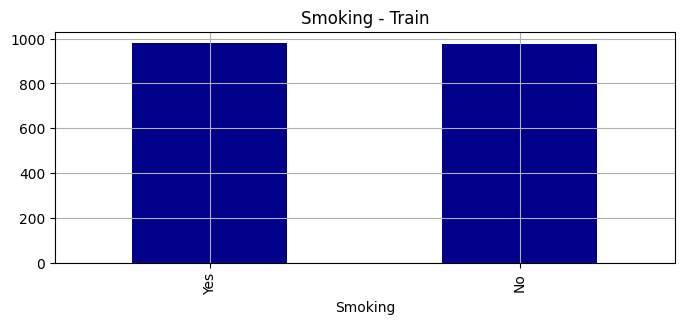

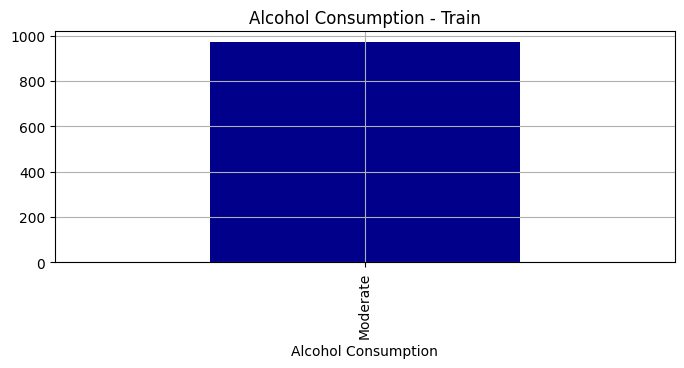

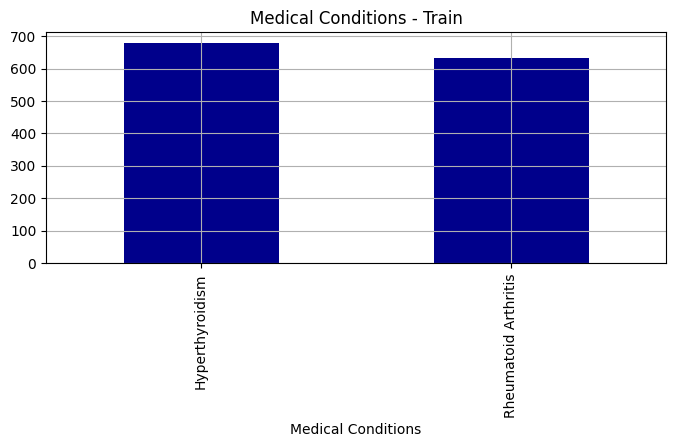

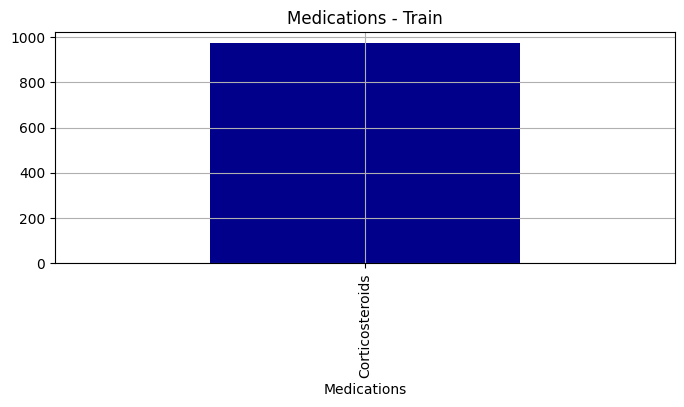

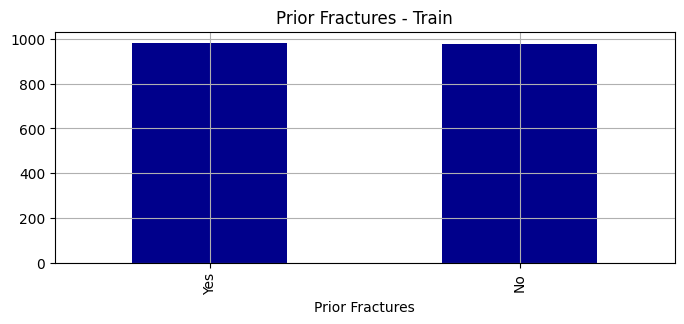

In [14]:
# plot categorical features (train and test)
for f in features_cat:
    plt.figure(figsize=(8,3))
    df[f].value_counts().plot(kind='bar', color='darkblue')
    plt.title(f + ' - Train')
    plt.grid()

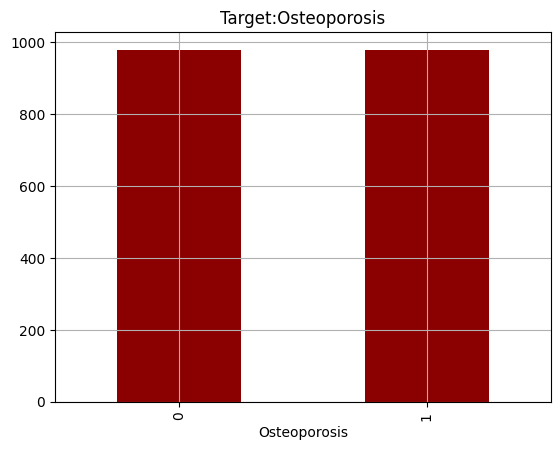

In [15]:
# plot target
df[target].value_counts().sort_index().plot(kind='bar', color=default_color_3)
plt.title("Target:" + target)
plt.grid()
plt.show()

In [16]:
# predictors
predictors = features_num + features_cat

print('Number of predictors:', len(predictors))
print()
print(predictors)

Number of predictors: 14

['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity', 'Body Weight', 'Calcium Intake', 'Vitamin D Intake', 'Physical Activity', 'Smoking', 'Alcohol Consumption', 'Medical Conditions', 'Medications', 'Prior Fractures']


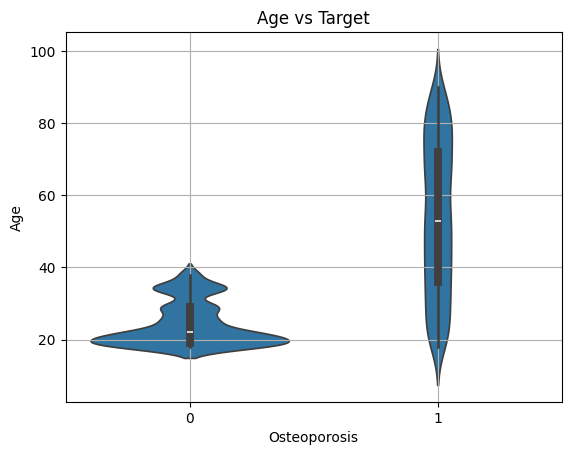

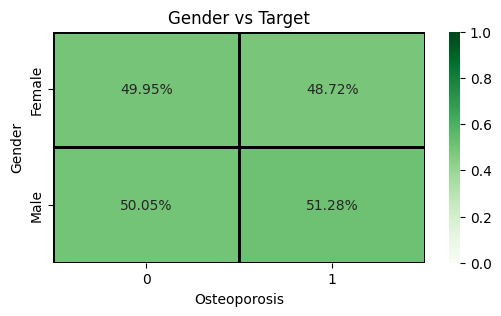

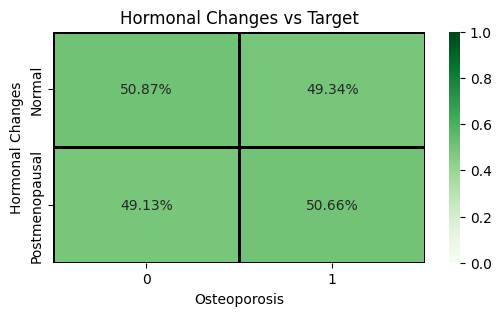

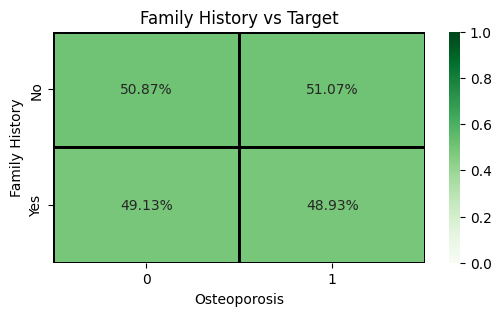

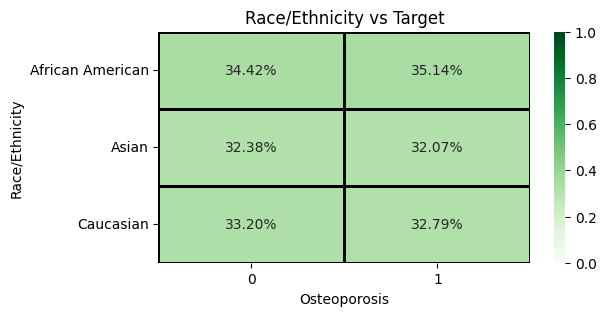

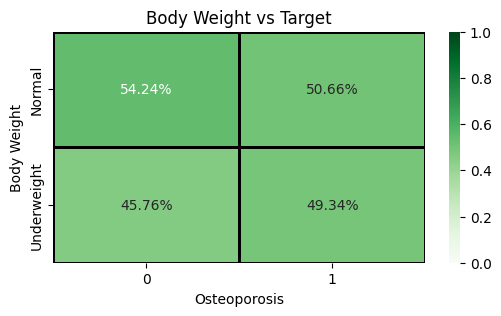

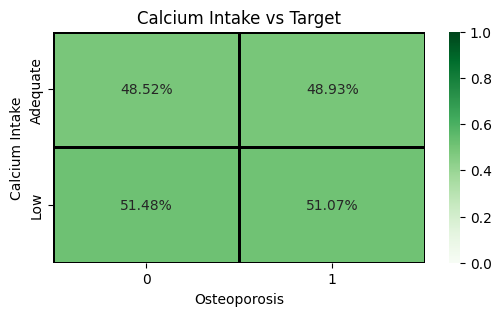

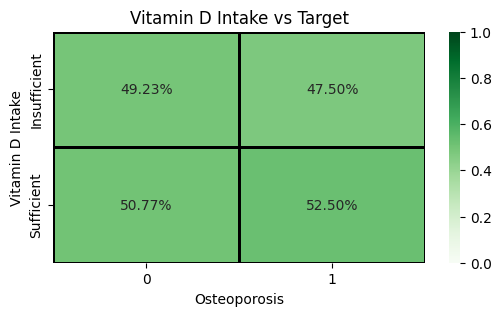

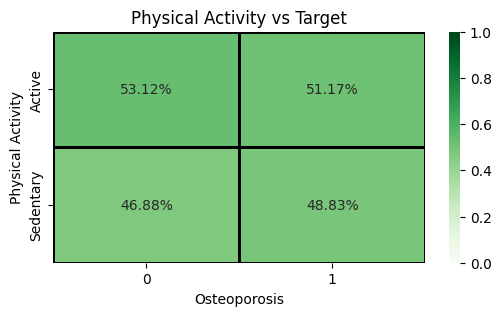

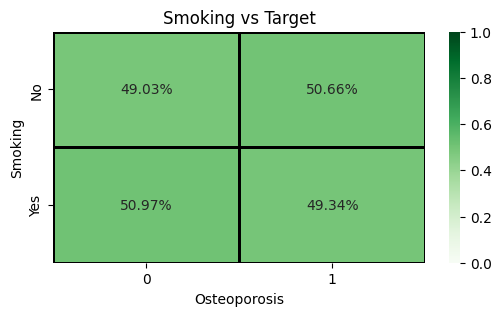

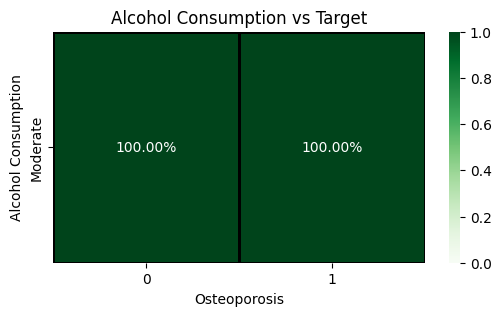

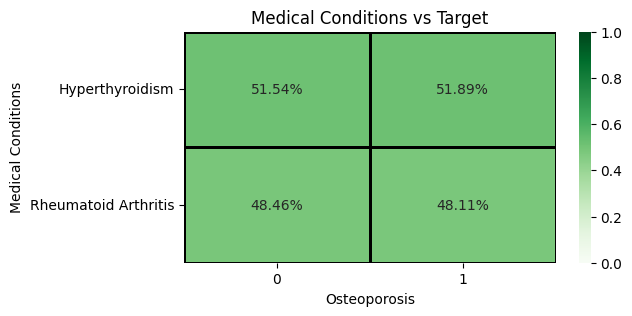

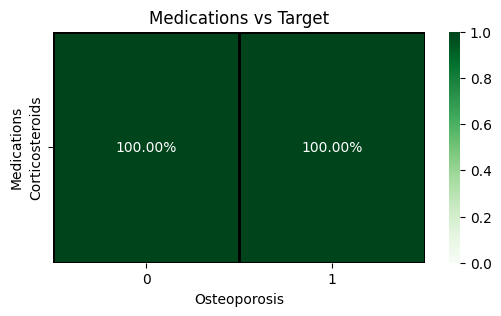

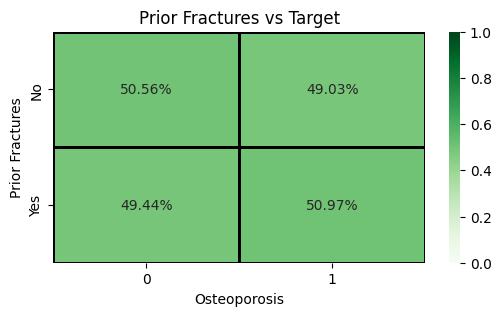

In [17]:
# plot distributions split by target
for f in predictors:
    if (f in features_num):
        sns.violinplot(data=df, x=target, y=f)
        plt.title(f + ' vs Target')
        plt.grid()
        plt.show()
    else:
        # calc cross table
        ctab = pd.crosstab(df[f],df[target])
        # ...and normalized by column
        ctab_norm = ctab / ctab.sum()
        # plot as heatmap
        plt.figure(figsize=(6,3))
        g = sns.heatmap(ctab_norm, annot=True,
                        fmt='.2%', linecolor='black',
                        linewidths=1,
                        cmap='Greens',
                        vmin=0, vmax=+1)
        plt.title(f + ' vs Target')
        plt.show()

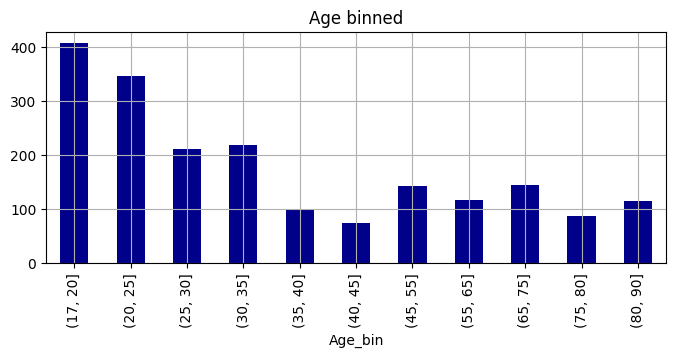

In [18]:
df['Age_bin'] = pd.cut(df.Age,[17,20,25,30,35,40,45,55,65,75,80,90])
plt.figure(figsize=(8,3))
df.Age_bin.value_counts().sort_index().plot(kind='bar', color=default_color_1)
plt.title('Age binned')
plt.grid()
plt.show()

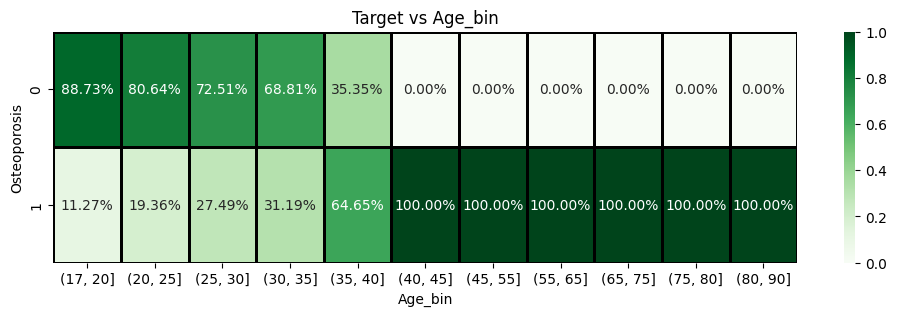

In [19]:
# mosaic plot for binned age
f = 'Age_bin'
ctab = pd.crosstab(df[target],df[f])
# ...and normalized by column
ctab_norm = ctab / ctab.sum()
# plot as heatmap
plt.figure(figsize=(12,3))
g = sns.heatmap(ctab_norm, annot=True,
                fmt='.2%', linecolor='black',
                linewidths=1,
                cmap='Greens',
                vmin=0, vmax=+1)
plt.title('Target vs ' + f)
plt.show()

In [20]:
# split data in train and test
perc_test = 0.25
df_train, df_test = train_test_split(df, test_size=perc_test, random_state=4321)

In [21]:
# reset indices to avoid trouble when later adding predictions
df_train.reset_index(inplace=True)
df_test.reset_index(inplace=True)

In [22]:
# start H2O
h2o.init(max_mem_size='12G', nthreads=4) # Use maximum of 12 GB RAM and 4 cores

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpd7x4t4me
  JVM stdout: /tmp/tmpd7x4t4me/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpd7x4t4me/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,26 days
H2O_cluster_name:,H2O_from_python_unknownUser_8qs1dg
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,12 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [23]:
# upload data in H2O environment
train_hex = h2o.H2OFrame(df_train)
test_hex = h2o.H2OFrame(df_test)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [24]:
# force categorical target
train_hex[target] = train_hex[target].asfactor()

In [25]:
# define GBM
mono_config = {'Age':1} # force monotone increasing impact of age
gbm_model = H2OGradientBoostingEstimator(nfolds = 5,
                                         ntrees = 25,
                                         learn_rate = 0.05,
                                         max_depth = 4,
                                         min_rows = 10,
                                         col_sample_rate = 0.7,
                                         monotone_constraints = mono_config,
                                         score_each_iteration = True,
                                         stopping_rounds=5,
                                         stopping_metric='auc',
                                         stopping_tolerance=0.0001,
                                         seed=12345)

In [26]:
# train model
gbm_model.train(predictors, target, training_frame = train_hex);

gbm Model Build progress: |██████████████████████████████████████████████████████| (done) 100%


In [27]:
# model details
gbm_model.show_summary()

,number_of_trees,number_of_internal_trees,model_size_in_bytes,min_depth,max_depth,mean_depth,min_leaves,max_leaves,mean_leaves
,14.0,14.0,3314.0,4.0,4.0,4.0,11.0,16.0,14.285714


In [28]:
# cross validation metrics
gbm_model.cross_validation_metrics_summary()

,mean,sd,cv_1_valid,cv_2_valid,cv_3_valid,cv_4_valid,cv_5_valid
accuracy,0.8653464,0.0118539,0.8591065,0.8529412,0.8720539,0.8825623,0.8600683
aic,nan,0.0,nan,nan,nan,nan,nan
auc,0.8935655,0.0119719,0.880967,0.9047363,0.8914468,0.9071501,0.8835275
err,0.1346536,0.0118539,0.1408935,0.1470588,0.1279461,0.1174377,0.1399317
err_count,39.6,4.449719,41.0,45.0,38.0,33.0,41.0
f0point5,0.9098560,0.0090125,0.9212731,0.9117647,0.8986928,0.9144296,0.9031199
f1,0.8506959,0.0107410,0.8429119,0.8464164,0.8527132,0.8685259,0.8429119
f2,0.799019,0.0199141,0.7768362,0.7898089,0.8112094,0.8270106,0.7902299
lift_top_group,2.0054338,0.0995076,1.9530201,1.8658537,2.1214285,2.0661764,2.0206897
loglikelihood,nan,0.0,nan,nan,nan,nan,nan


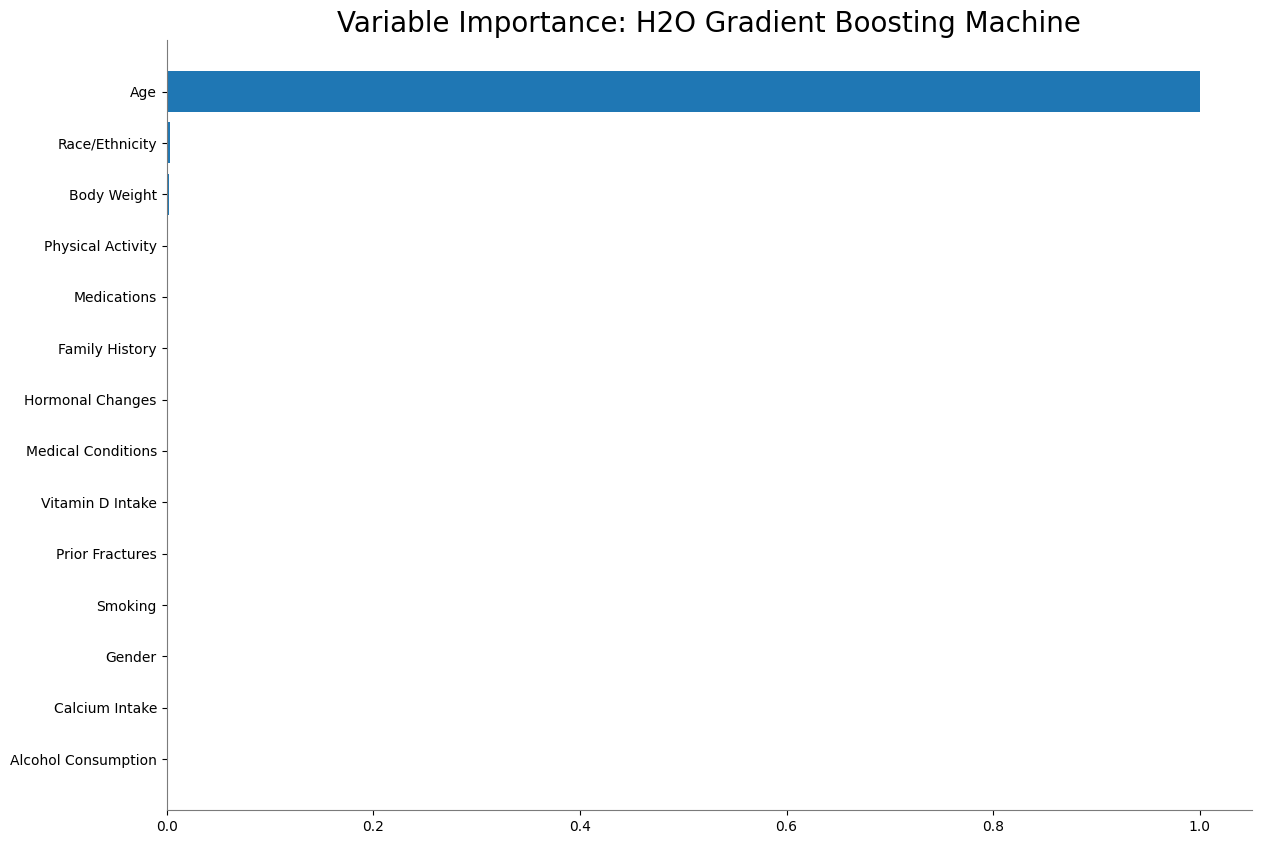

<Figure size 640x480 with 0 Axes>

In [29]:
# variable importance
gbm_model.varimp_plot(20)
plt.show()

In [35]:
# predict on train data
pred_train = gbm_model.predict(train_hex).as_data_frame()
# add predictions to data frame
df_train['pred_GBM'] = pred_train.p1
df_train['pred_GBM_class'] = pred_train.predict

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [36]:
# compare frequencies
print('Actual Frequency:   ', df_train[target].sum())
print('Predicted Frequency:', np.round(df_train.pred_GBM.sum(),3))

Actual Frequency:    734
Predicted Frequency: 733.277


In [37]:
# check actual confusion matrix
pd.crosstab(df_train.pred_GBM_class, df_train[target])

Osteoporosis,0,1
pred_GBM_class,,
0,689,154
1,45,580


In [38]:
# predict on test data
pred_test = gbm_model.predict(test_hex).as_data_frame()
# add predictions to data frame
df_test['pred_GBM'] = pred_test.p1
df_test['pred_GBM_class'] = pred_test.predict

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [39]:
# basic stats
df_test.pred_GBM.describe()

,pred_GBM
count,490.000000
mean,0.495090
std,0.195758
min,0.284104
25%,0.321583
50%,0.395266
75%,0.752668
max,0.755059


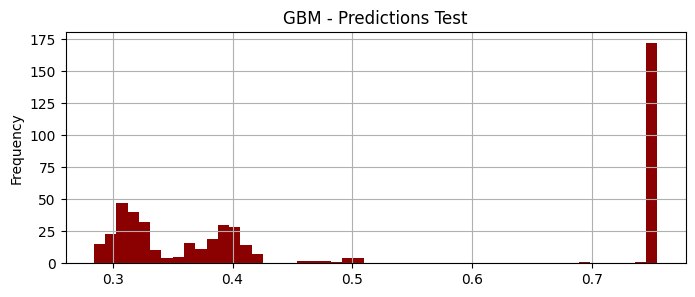

In [40]:
# plot distribution of predictions
plt.figure(figsize=(8,3))
df_test.pred_GBM.plot(kind='hist', bins=50,
                      color=default_color_3)
plt.title('GBM - Predictions Test')
plt.grid()
plt.show()

In [41]:
# compare frequencies
print('Actual Frequency:   ', df_test[target].sum())
print('Predicted Frequency:', np.round(df_test.pred_GBM.sum(),3))

Actual Frequency:    245
Predicted Frequency: 242.594


In [42]:
# show first rows of test set incl. predictions
df_test.head(10)

,index,Id,Age,Gender,Hormonal Changes,Family History,Race/Ethnicity,Body Weight,Calcium Intake,Vitamin D Intake,Physical Activity,Smoking,Alcohol Consumption,Medical Conditions,Medications,Prior Fractures,Osteoporosis,Age_bin,pred_GBM,pred_GBM_class
0,1877,1190006,29,Male,Postmenopausal,No,Caucasian,Underweight,Adequate,Insufficient,Sedentary,Yes,Moderate,Hyperthyroidism,NaN,Yes,0,"(25, 30]",0.405142,0
1,766,1927663,64,Male,Normal,Yes,Caucasian,Normal,Adequate,Sufficient,Active,Yes,Moderate,Hyperthyroidism,Corticosteroids,Yes,1,"(55, 65]",0.751672,1
2,376,1898951,74,Male,Normal,No,African American,Underweight,Low,Insufficient,Sedentary,Yes,NaN,Hyperthyroidism,Corticosteroids,Yes,1,"(65, 75]",0.754276,1
3,1005,1952835,19,Female,Postmenopausal,No,Caucasian,Normal,Low,Sufficient,Active,Yes,NaN,NaN,NaN,No,0,"(17, 20]",0.304148,0
4,774,1864281,23,Male,Normal,Yes,Caucasian,Underweight,Adequate,Insufficient,Sedentary,No,NaN,Hyperthyroidism,NaN,Yes,1,"(20, 25]",0.327901,0
5,925,1364919,52,Male,Normal,No,Asian,Underweight,Low,Sufficient,Sedentary,No,Moderate,Hyperthyroidism,NaN,No,1,"(45, 55]",0.752851,1
6,974,1849905,55,Male,Normal,No,Asian,Underweight,Low,Sufficient,Sedentary,Yes,NaN,NaN,NaN,No,1,"(45, 55]",0.754684,1
7,990,1347282,29,Male,Postmenopausal,No,Caucasian,Normal,Low,Insufficient,Active,Yes,Moderate,Rheumatoid Arthritis,NaN,No,0,"(25, 30]",0.371129,0
8,1582,1610085,19,Male,Postmenopausal,No,Asian,Underweight,Adequate,Sufficient,Active,No,NaN,Hyperthyroidism,Corticosteroids,No,0,"(17, 20]",0.321530,0
9,541,1784524,20,Male,Normal,No,Asian,Normal,Low,Insufficient,Sedentary,No,NaN,NaN,Corticosteroids,Yes,1,"(17, 20]",0.334702,0


In [43]:
# check confusion matrix
pd.crosstab(df_test.pred_GBM_class, df_test[target])

Osteoporosis,0,1
pred_GBM_class,,
0,232,59
1,13,186


In [46]:
model_path = h2o.save_model(model=gbm_model, path="/content", force=True)
print(model_path)

/content/GBM_model_python_1775637595793_1
